In [30]:
import numpy as np
import matplotlib.pyplot as plt

from tree import Tree
from tree_tensor import TreeBasedTensor
from tree_cross import TreeCross

rng = np.random.default_rng()

In [31]:
Nx = 100    # spatial resolution
Ny = 5       # parameter resolution
n_a_param = 5 # number of parameters for diffusion coeff
n_param = n_a_param
offset = 1   # parameter mean
var = 4       # 'variance' of the parameters
tol = 1e-4

In [32]:
class diffusion_coeff:
  def __init__(self, Nx, Ny, offset, var):
    self.Nx = Nx
    self.Ny = Ny
    self.offset = offset
    self.var = var

  def __call__(self, X):
    c = np.full(len(X), self.offset,dtype=float)
    for i, x in enumerate(X):
      k = np.arange(1,len(x)-1)
      # k = k[k != 7]
      c[i] += np.sum(k**-2. * np.sin(np.pi*k*x[0]/(self.Nx-1)) \
                      * (x[k]/(self.Ny-1) - 0.5) * self.var)
    return c
  
def err_MC(tensor, cfun, N_MC=500):
  N_MC = 500
  errs = np.zeros(N_MC)

  for i in range(N_MC):
    # eval TT-approx of coeff
    y = rng.integers(0, Ny, n_a_param)
    C_eval = np.ravel(tensor[:, *y])

    X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
    C_true = cfun(X)

    errs[i] = np.linalg.norm(C_eval-C_true)

  return errs

In [33]:

cfun = diffusion_coeff(Nx, Ny, offset, var)

param_shape = tuple([Ny] * n_param)

# tree = Tree.from_tupletree((0,(1,((2,3), (4,(5,6))))))
tree = Tree.from_tupletree((0,(1,((2,3), (4,5)))))
# tree = Tree.from_tupletree((0,(1,((2,3), ((4,5),(6,7))))))
# tree = Tree.from_tupletree((0,(((1,2),(3,4)),((5,6),(7,8)))))
# tree = Tree.from_tupletree((0,(1,(2,(3,(4,(5,(6,(7,(8,))))))))))
# tree = Tree.from_tupletree((0,(1,(2,(3,(4,))))))
# tree = Tree.from_tupletree((0,((1,2),(3,4))))

# tree = Tree.from_tupletree((0,(1,(2,(3,)))))
tree.print()
C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

res = {}
for kickrank in [0,1,2,3,4,10]:
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, 2)
  res[kickrank] = {'n_eval':[], 'err':[]}
  n_eval_over_iter = []
  cross = TreeCross(C_a)
  while cross.n_eval < 1e5:
    cross.run(cfun, n_iter=1, eps=1e-12, kickrank=kickrank, verbose=False)
    # C_a.print()

    C_a_test = C_a.copy()
    C_a_test.round(tol=tol)
    # C_a_test.print()
    errs = err_MC(C_a_test, cfun)

    res[kickrank]['err'] += [np.sqrt(np.mean(np.square(errs)))]
    res[kickrank]['n_eval'] += [cross.n_eval]

C_a_test.print()

[10] (root) 
 + [0] (dim 0)
 + [9] 
    + [1] (dim 1)
    + [8] 
       + [4] 
       |  + [2] (dim 2)
       |  + [3] (dim 3)
       + [7] 
          + [5] (dim 4)
          + [6] (dim 5)

Tree tensor with shape (100, 5, 5, 5, 5, 5)
[10] root ranks=(5, 5, 1)
 + [0] dim 0 of size 100
 + [9] ranks=(2, 4, 5)
    + [1] dim 1 of size 5
    + [8] ranks=(3, 2, 4)
       + [4] ranks=(2, 2, 3)
       |  + [2] dim 2 of size 5
       |  + [3] dim 3 of size 5
       + [7] ranks=(2, 1, 2)
          + [5] dim 4 of size 5
          + [6] dim 5 of size 5


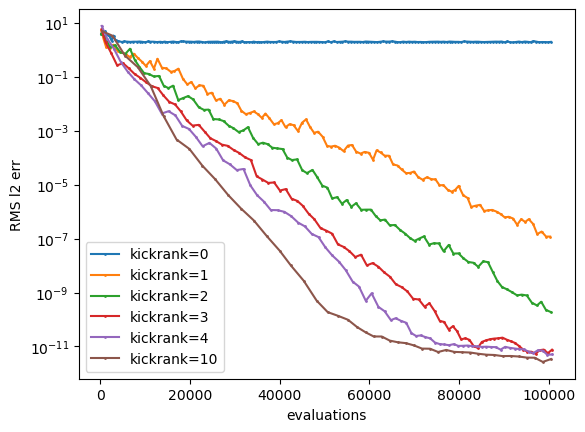

In [34]:
fig, ax = plt.subplots()
for kickrank, data in res.items():
  ax.plot(data['n_eval'], data['err'], marker='o', ms=1, label=f'kickrank={kickrank}')
ax.set_yscale('log')
ax.set_ylabel('RMS l2 err')
ax.set_xlabel('evaluations')
ax.legend()

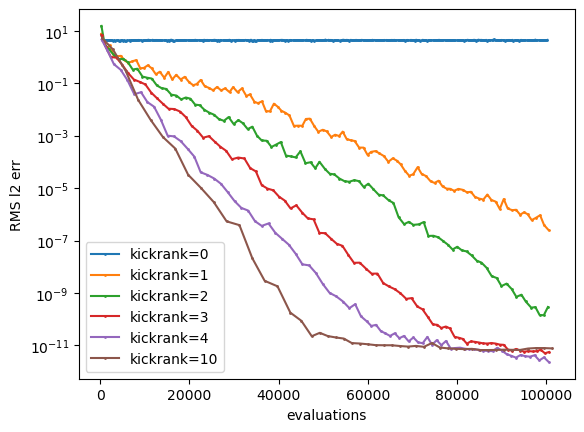

In [24]:
fig, ax = plt.subplots()
for kickrank, data in res.items():
  ax.plot(data['n_eval'], data['err'], marker='o', ms=1, label=f'kickrank={kickrank}')
ax.set_yscale('log')
ax.set_ylabel('RMS l2 err')
ax.set_xlabel('evaluations')
ax.legend()

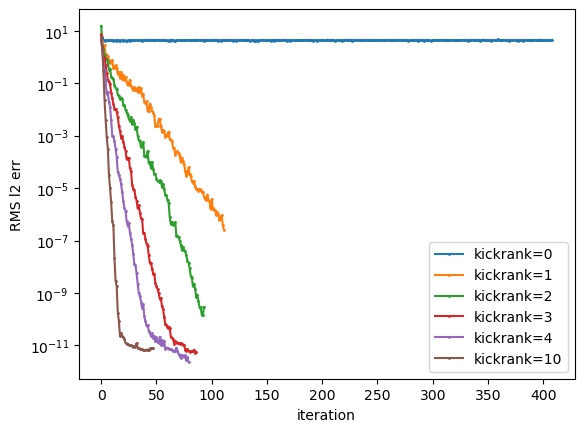

In [23]:
fig, ax = plt.subplots()
for kickrank, data in res.items():
  ax.plot(data['err'], marker='o', ms=1, label=f'kickrank={kickrank}')
ax.set_yscale('log')
ax.set_ylabel('RMS l2 err')
ax.set_xlabel('iteration')
ax.legend()

RMS l2 err = 9.20e-08


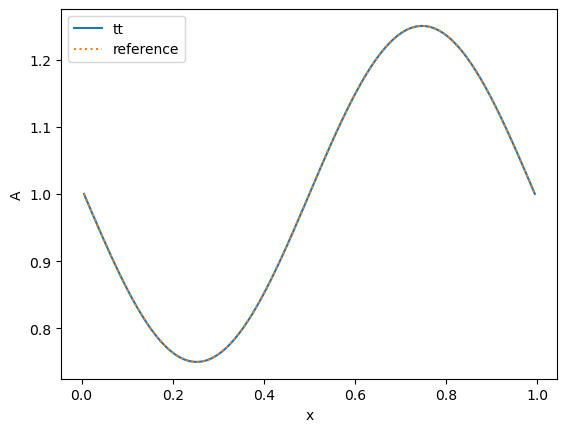

In [196]:
N_MC = 500
errs = np.zeros(N_MC)

for i in range(N_MC):
  # eval TT-approx of coeff
  y = rng.integers(0, Ny, n_a_param)
  C_eval = np.ravel(C_a[:, *y])

  X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
  C_true = cfun(X)

  errs[i] = np.linalg.norm(C_eval-C_true)

print(f'RMS l2 err = {np.sqrt(np.mean(np.square(errs))):.2e}')

fig, ax = plt.subplots()

x = (np.arange(0, Nx) + .5) / Nx
ax.plot(x, C_eval, label='tt')
ax.plot(x, C_true, ls='dotted', label="reference")
ax.set_xlabel('x')
ax.set_ylabel('A')
ax.legend()

In [197]:
runs = 10

errs_linear = []
evals_linear = []

for run in range(runs):
  tree = Tree.from_tupletree((0,(1,(2,(3,(4,(5,(6,(7,8)))))))))
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

  cross = TreeCross(C_a)
  cross.run(cfun, n_iter=25, eps=1e-9, kickrank=40, verbose=False)
  C_a.round(tol=tol)

  errs = err_MC(C_a, cfun)

  errs_linear += [np.sqrt(np.mean(np.square(errs)))]
  evals_linear += [cross.n_eval]

AssertionError: Tree order must match shape (9 != 4).

In [ ]:
errs_fancy = []
evals_fancy = []

for run in range(runs):
  tree = Tree.from_tupletree((0,(1,((2,(3,4), (5,(6,(7,8))))))))
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

  cross = TreeCross(C_a)
  cross.run(cfun, n_iter=25, eps=1e-9, kickrank=40, verbose=False)
  C_a.round(tol=tol)

  errs = err_MC(C_a, cfun)

  errs_fancy += [np.sqrt(np.mean(np.square(errs)))]
  evals_fancy += [cross.n_eval]

In [ ]:
errs_balanced = []
evals_balanced = []

for run in range(runs):
  tree = Tree.from_tupletree((0,(((1,2),(3,4)),((5,6),(7,8)))))
  C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

  cross = TreeCross(C_a)
  cross.run(cfun, n_iter=25, eps=1e-9, kickrank=40, verbose=False)
  C_a.round(tol=tol)

  errs = err_MC(C_a, cfun)

  errs_balanced += [np.sqrt(np.mean(np.square(errs)))]
  evals_balanced += [cross.n_eval]

In [ ]:
print(np.mean(evals_linear))
print(np.mean(evals_fancy))
print(np.mean(evals_balanced))

253897.5
253056.5
254680.0


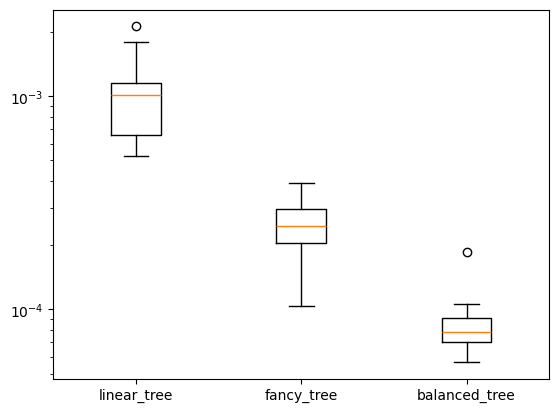

In [ ]:
fig, ax = plt.subplots()

ax.boxplot([errs_linear,errs_fancy, errs_balanced], tick_labels=['linear_tree', 'fancy_tree', 'balanced_tree'])
ax.set_yscale('log')